In [41]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import plotly.express as px

import utility_functions as uf

In [81]:
n_years = 5
mode = "individual"

df_cs_yearly_full = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2]).xs(mode, level=2).dropna(how="all")
df_prob_yearly_full = df_cs_yearly_full.div(df_cs_yearly_full.sum(axis=1), axis=0)

df_cs_roll_yearly_full = (
    df_cs_yearly_full
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .dropna(how="all")
    .reset_index(level=0, drop=True)
    
)
df_prob_roll_yearly_full = df_cs_roll_yearly_full.div(df_cs_roll_yearly_full.sum(axis=1), axis=0)

In [84]:
df_cs_roll_yearly_full

1100  1102  1103  1104  1105  1106  1107  1108  1109   1110  \
country year                                                                
AE      1974   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   
        1975   NaN   NaN  19.0   NaN   NaN  10.0   NaN   NaN   NaN    NaN   
        1976   NaN   NaN  19.0   NaN   NaN  10.0   NaN   NaN   NaN    NaN   
        1977   NaN   NaN  19.0   NaN   NaN  11.0   NaN   NaN   NaN    NaN   
        1978   NaN   NaN  18.0   NaN   NaN  11.0   NaN   NaN   NaN    NaN   
...            ...   ...   ...   ...   ...   ...   ...   ...   ...    ...   
ZW      2019  23.0  16.0  15.0   NaN  32.0  32.0   NaN   NaN   NaN   76.0   
        2020  23.0  19.0  19.0   NaN  29.0  27.0   NaN   NaN   NaN   80.0   
        2021  29.0  25.0  19.0   NaN  35.0  23.0   NaN   NaN   NaN   92.0   
        2022  33.0  27.0  20.0   NaN  40.0  30.0   NaN   NaN   NaN  101.0   
        2023  40.0  27.0  17.0   NaN  42.0  44.0  19.0   NaN  20.0  102.0   

              ...  3604  3605  3607  3608  3609  3611  3612  3614  3616  3002  
country year  ...                                                              
AE      1974  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1975  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1976  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1977  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        1978  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
...           ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  
ZW      2019  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2020  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2021  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2022  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
        2023  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  

[6839 rows x 252 columns]

In [83]:
df_cs_yearly_full

,,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3604,3605,3607,3608,3609,3611,3612,3614,3616,3002
country,year,,,,,,,,,,,,,,,,,,,,,
AE,1970,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
AF,1970,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AM,1970,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AO,1970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AR,1970,6.0,1.0,2.0,NaN,31.0,12.0,4.0,NaN,1.0,22.0,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,2023,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,2023,NaN,NaN,NaN,1.0,4.0,8.0,NaN,NaN,2.0,14.0,...,8.0,6.0,1.0,NaN,NaN,NaN,NaN,4.0,2.0,NaN
ZA,2023,67.0,73.0,49.0,22.0,157.0,156.0,22.0,NaN,86.0,459.0,...,38.0,22.0,5.0,NaN,33.0,21.0,12.0,55.0,47.0,NaN


In [43]:
df_total_articles = (
    pd.DataFrame({}, index=df_cs_yearly_full.index)
    .assign(
        total = df_cs_yearly_full.sum(axis=1),
        total_roll = df_cs_roll_yearly_full.sum(axis=1)
    )
)

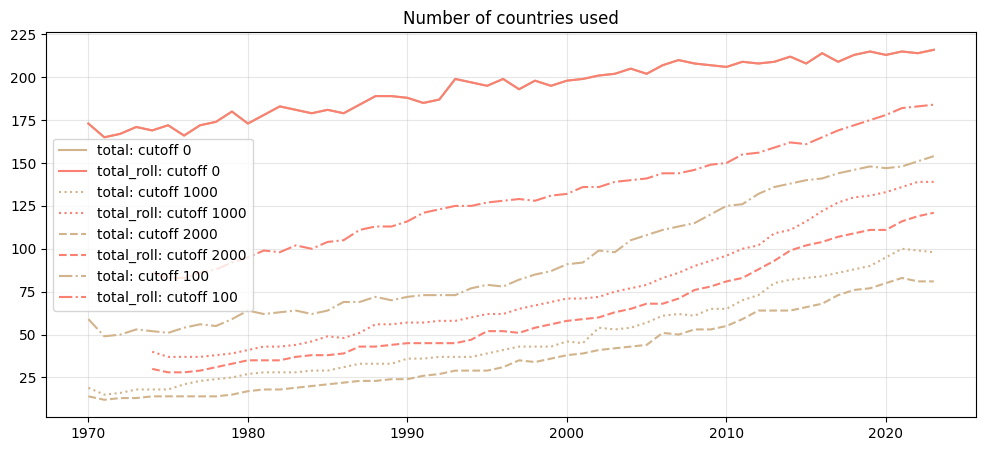

In [44]:
cap_articles_list = [0, 1000,  2000, 100, ]
param_list = ["total", "total_roll"]

color_param = {
    "total": "tan", "total_roll": "salmon"
}
linestyle_cap = {
    0: "-", 2000: "--", 100: "-.", 1000: ":"
}

plt.subplots(figsize=(12, 5))

for cap_articles_loop in cap_articles_list:
    for param in param_list:
        tmp = df_total_articles.query(param+" >= @cap_articles_loop").groupby(level=1)[param].count()
        plt.plot(tmp.index, tmp.values,
                 color = color_param[param], linestyle = linestyle_cap[cap_articles_loop],
                 label=f"{param}: cutoff {cap_articles_loop}")
plt.grid(alpha=0.3)
_ = plt.title("Number of countries used")
_ = plt.legend()

In [45]:
df_cutoff = (
    df_total_articles
    .assign(
        cutoff_5000 = lambda df: (df.total >= 5000).astype(int),
        cutoff_roll_5000 = lambda df: (df.total_roll >= 5000).astype(int),
        cutoff_2000 = lambda df: (df.total >= 2000).astype(int),
        cutoff_roll_2000 = lambda df: (df.total_roll >= 2000).astype(int),
        cutoff_1000 = lambda df: (df.total >= 1000).astype(int),
        cutoff_roll_1000 = lambda df: (df.total_roll >= 1000).astype(int),
        cutoff_500 = lambda df: (df.total >= 500).astype(int),
        cutoff_roll_500 = lambda df: (df.total_roll >= 500).astype(int)
    )
)

In [46]:
df_cutoff

,,total,total_roll,cutoff_5000,cutoff_roll_5000,cutoff_2000,cutoff_roll_2000,cutoff_1000,cutoff_roll_1000,cutoff_500,cutoff_roll_500
country,year,,,,,,,,,,
AE,1970,34.0,0.0,0,0,0,0,0,0,0,0
AF,1970,5.0,0.0,0,0,0,0,0,0,0,0
AM,1970,65.0,0.0,0,0,0,0,0,0,0,0
AO,1970,2.0,0.0,0,0,0,0,0,0,0,0
AR,1970,873.0,0.0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
WS,2023,12.0,68.0,0,0,0,0,0,0,0,0
YE,2023,949.0,2606.0,0,0,0,1,0,1,1,1
ZA,2023,19694.0,94913.0,1,1,1,1,1,1,1,1


<BarContainer object of 4 artists>

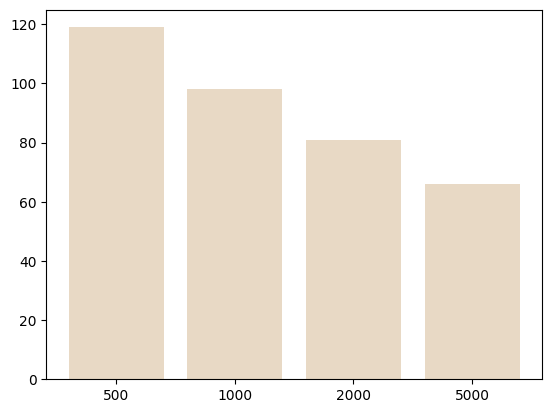

In [47]:
year = 2023
cutoff_list = ["500", "1000", "2000", "5000"]
plt.bar(cutoff_list, df_cutoff.query("year == @year")[[f"cutoff_{cutoff}" for cutoff in cutoff_list]].sum().values, color="tan", alpha=0.5, label="raw")

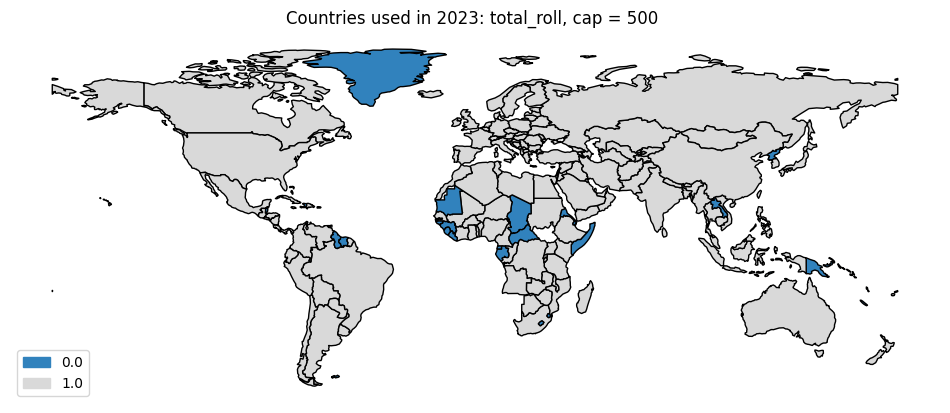

In [48]:
year = 2023

cap_plot = 500
param_plot = "total_roll"

df_plot = (
    df_total_articles
    .xs(year, level=1)
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2", how="left")
    .assign(cutoff = lambda df: (df[param_plot] >= cap_plot).astype(int))
)

_ = uf.plot_map_discrete(df_plot, "cutoff", title=f"Countries used in {year}: {param_plot}, cap = {cap_plot}")

# Rolling and distances

## Distance between roling and usual

In [9]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [10]:
df_prob_yearly_full

,,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3604,3605,3607,3608,3609,3611,3612,3614,3616,3002
country,year,,,,,,,,,,,,,,,,,,,,,
AE,1970,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
AF,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
AG,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
AL,1970,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
AM,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,2023,0.029412,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.058824,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
YE,2023,0.001517,0.003794,0.002276,0.002276,0.003035,0.008346,0.000000,0.000000,0.002276,0.019727,...,0.000759,0.002276,0.001517,0.0,0.000000,0.000000,0.000759,0.002276,0.000000,0.0
ZA,2023,0.003345,0.003903,0.003265,0.001673,0.012902,0.007646,0.001035,0.000000,0.005973,0.024450,...,0.001673,0.001115,0.000558,0.0,0.001593,0.000558,0.000478,0.002310,0.001513,0.0


In [11]:
country = "FR"
df1 = df_prob_yearly_full.xs(year, level=1)
df2 = df_prob_roll_yearly_full.xs(year, level=1)

index_list = df1.index.to_list()

pd.DataFrame(np.diagonal(uf.get_w1_distances_matrix(df1, df2).loc[index_list, index_list].values),
             index=df1.index,
             columns=["dist"]).assign(year=year)

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: divide by zero encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: overflow encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: invalid value encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning: divide by zero encountered in matmul
  np.sum(np.abs(wass_array_short @ df_diff.fillna(0).values.T), axis=0),
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning: overflow encountered in matmul
  np.sum(np.abs(wass_array_short @ df_diff.fillna(0).values.T), a

,dist,year
country,,
AD,0.136808,2023
AE,0.008406,2023
AF,0.048721,2023
AG,0.018915,2023
AL,0.050630,2023
...,...,...
WS,0.117556,2023
YE,0.051899,2023
ZA,0.014932,2023


In [12]:
year_list = df_prob_roll_yearly_full.xs("US").dropna(how="all").index.to_list()

In [13]:
year = 2023
country = "RU"

df_dist_roll_non_roll_list = []

for year_loop in tqdm(year_list):
    df1 = df_prob_yearly_full.xs(year, level=1)
    df2 = df_prob_roll_yearly_full.xs(year, level=1)

    index_list = df1.index.to_list()

    df_dist_roll_non_roll_list.append(pd.DataFrame(np.diagonal(uf.get_w1_distances_matrix(df1, df2).loc[index_list, index_list].values),
                index=df1.index,
                columns=["dist"]).assign(year=year_loop))

  0%|          | 0/50 [00:00<?, ?it/s]/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: divide by zero encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: overflow encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: invalid value encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning: divide by zero encountered in matmul
  np.sum(np.abs(wass_array_short @ df_diff.fillna(0).values.T), axis=0),
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning: overflow encountered in matmul
  np.sum(np.abs(wass_array_

In [14]:
df_dist_roll_non_roll = pd.concat(df_dist_roll_non_roll_list).reset_index().set_index(["country", "year"])

In [15]:
country_list = ["US", "CN", "ID", "FR"]

cutoff = 2000

df_plot = (
    df_dist_roll_non_roll
    .merge(df_cutoff, left_index=True, right_index=True)
    .reset_index()
    .query("cutoff_roll_"+str(cutoff)+" == 1")
)

fig = px.box(df_plot, x="year", y="dist", hover_data="country", title=f"W1-tree distance between raw and rolling profiles (cutoff {cutoff})")


fig.update_traces(
    marker=dict(color="grey"),
    line=dict(color="grey"),
    opacity=0.5
)
for country in country_list:
    fig.add_scatter(
        x=df_dist_roll_non_roll.xs(country, level=0).index,
        y=df_dist_roll_non_roll.xs(country, level=0).dist,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()

In [16]:
# uf.get_subfield_info(1908)

In [17]:
country = "US"
year = 2002

df_profile_country = pd.concat([
            df_prob_yearly_full.loc[(country, year)],
            df_prob_roll_yearly_full.loc[(country, year)]
        ], axis=1).T.reset_index(drop=True).T.rename(columns={0: "Pure", 1: "Rolling"})
px.bar(df_profile_country, x=df_profile_country.index, y=["Pure", "Rolling"], barmode="overlay",
       title=f"Pure vs Rolling 5 years profiles: {uf.id2name_country[country]}, {year}")


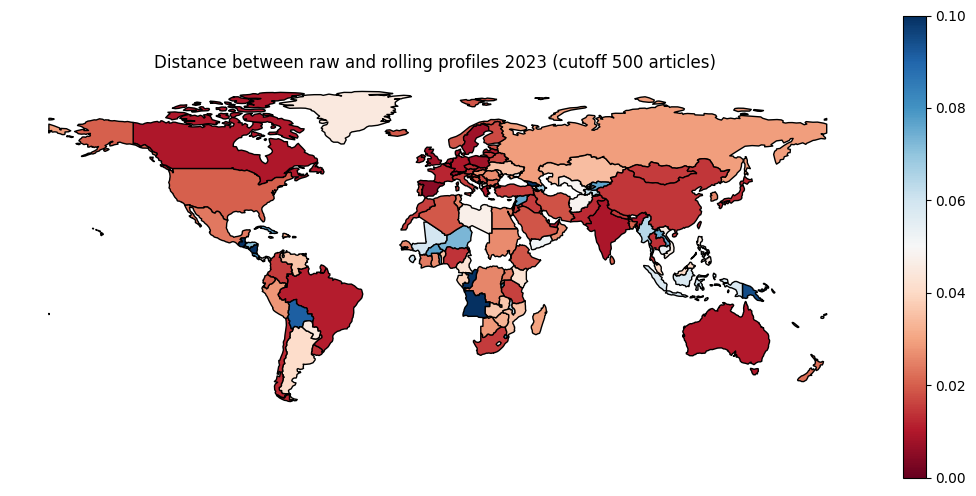

In [18]:
year = 2023
cutoff =500

df_plot = (
    df_dist_roll_non_roll.xs(year, level=1)
    .merge(df_cutoff.xs(year, level=1), left_index=True, right_index=True)
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
    .query("cutoff_roll_"+str(cutoff)+" == 1")
)
_ = uf.plot_map_continuous(df_plot, "dist", range=(0, 0.1), title=f"Distance between raw and rolling profiles {year} (cutoff {cutoff} articles)")

## Compare country distances rolling 

In [49]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [50]:
year = 2015

# df_dist = uf.get_w1_distances(subfield_tree, df_prob_yearly_full.xs(year, level=1))
df_dist = uf.get_w1_distances_matrix(df_prob_yearly_full.xs(year, level=1), df_prob_yearly_full.xs(year, level=1))
df_dist_rolling = uf.get_w1_distances_matrix(df_prob_roll_yearly_full.xs(year, level=1), df_prob_roll_yearly_full.xs(year, level=1))
# df_dist_rolling = uf.get_w1_distances(subfield_tree, df_prob_roll_yearly_full.xs(year, level=1))

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/util

In [21]:
df = (
    df_dist.sub(df_dist_rolling)
)

cutoff = 1000
country_list_sorted = df_total_articles.xs(year, level=1).sort_values("total", ascending=False).query("total_roll >= @cutoff").index.to_list()

uf.plotly_heatmap(df.loc[country_list_sorted, country_list_sorted],
                  y_labels=country_list_sorted, x_labels=country_list_sorted,
                  z_min=-0.5, z_max=0.5, x_type="country", y_type="country",
                  title=f"(Distance raw - Distance rolling), {year}, cutoff = {cutoff}")

## Distance dynanics

In [90]:
start_year = 1974
end_year = 2023

n_years = 5
mode = "individual"

df_cs_yearly_full = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2]).xs(mode, level=2).fillna(0)
df_prob_yearly_full = df_cs_yearly_full.div(df_cs_yearly_full.sum(axis=1), axis=0)

df_cs_roll_yearly_full = (
    df_cs_yearly_full
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
# df_prob_roll_yearly_full = df_cs_roll_yearly_full.div(df_cs_roll_yearly_full.sum(axis=1), axis=0)

df_dist_list = []
df_dist_rolling_list = []

for year_loop in tqdm(range(start_year, end_year+1)):
    df1 = df_prob_yearly_full.xs(year_loop, level=1)
    df2 = df_prob_roll_yearly_full.xs(year_loop, level=1)

    df_dist = uf.get_w1_distances_matrix(df1, df1).assign(year=year_loop).assign(year=year_loop).reset_index(names="country")
    np.fill_diagonal(df_dist.values, np.nan)
    df_dist_list.append(df_dist)
    if df_prob_roll_yearly_full.xs(year_loop, level=1).empty:
        continue
    df_dist_rolling = uf.get_w1_distances_matrix(df2, df2).assign(year=year_loop).assign(year=year_loop).reset_index(names="country")
    np.fill_diagonal(df_dist_rolling.values, np.nan)
    df_dist_rolling_list.append(df_dist_rolling)


df_dist_yearly = pd.concat(df_dist_list).set_index(["country", "year"])
df_dist_rolling_yearly = pd.concat(df_dist_rolling_list).set_index(["country", "year"])

  0%|          | 0/50 [00:00<?, ?it/s]/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology

In [91]:
# start_year = 1970
# end_year = 2023

# n_years = 5
# mode = "collaborative"

# df_cs_yearly_full = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2]).xs(mode, level=2).fillna(0)
# df_prob_yearly_full = df_cs_yearly_full.div(df_cs_yearly_full.sum(axis=1), axis=0)

# df_cs_roll_yearly_full = (
#     df_cs_yearly_full
#     .sort_index()
#     .groupby(level=0)
#     .rolling(n_years).sum()
#     .reset_index(level=0, drop=True)
# )
# df_prob_roll_yearly_full_col = df_cs_roll_yearly_full.div(df_cs_roll_yearly_full.sum(axis=1), axis=0)

# df_dist_list = []
# df_dist_rolling_list = []

# for year_loop in tqdm(range(start_year, end_year+1)):
#     df1 = df_prob_yearly_full.xs(year_loop, level=1)
#     df2 = df_prob_roll_yearly_full_col.xs(year_loop, level=1)

#     df_dist = uf.get_w1_distances_matrix(df1, df1).assign(year=year_loop).assign(year=year_loop).reset_index(names="country")
#     np.fill_diagonal(df_dist.values, np.nan)
#     df_dist_list.append(df_dist)
#     if df_prob_roll_yearly_full_col.xs(year_loop, level=1).empty:
#         continue
#     df_dist_rolling = uf.get_w1_distances_matrix(df2, df2).assign(year=year_loop).assign(year=year_loop).reset_index(names="country")
#     np.fill_diagonal(df_dist_rolling.values, np.nan)
#     df_dist_rolling_list.append(df_dist_rolling)


# df_dist_yearly_col = pd.concat(df_dist_list).set_index(["country", "year"])
# df_dist_rolling_yearly_col = pd.concat(df_dist_rolling_list).set_index(["country", "year"])

In [92]:
# mode = "collaborative"

In [93]:
# df_dist_rolling_yearly.to_csv(uf.PATH+f"df_dist_w1_rolling_yearly_{mode}.csv")
# df_dist_yearly.to_csv(uf.PATH+f"df_dist_w1_yearly_{mode}.csv")

In [94]:
# df_dist_yearly = pd.read_csv(uf.PATH+f"df_dist_w1_yearly_{mode}.csv", index_col=[0, 1])
# df_dist_rolling_yearly = pd.read_csv(uf.PATH+f"df_dist_w1_rolling_yearly_{mode}.csv", index_col=[0, 1])

In [95]:
df_dist_rolling_yearly

,idx2,AE,AM,AR,AT,AU,AZ,BE,BG,BR,BY,...,CF,FO,SR,TL,WS,AG,HT,MR,MS,TD
country,year,,,,,,,,,,,,,,,,,,,,,
AE,1974,0.000000,1.000000,0.765204,0.752202,0.768639,1.000000,0.815909,0.912027,0.812008,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AM,1974,1.000000,0.000000,0.670573,0.543153,0.656664,0.063939,0.529376,0.256352,0.728290,0.121734,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AR,1974,0.765204,0.670573,0.000000,0.161676,0.140637,0.658943,0.217328,0.445960,0.231798,0.619503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AT,1974,0.752202,0.543153,0.161676,0.000000,0.141789,0.527557,0.081455,0.312208,0.268510,0.487417,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AU,1974,0.768639,0.656664,0.140637,0.141789,0.000000,0.645151,0.135304,0.429253,0.133825,0.600805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,2023,0.738784,0.624839,0.539355,0.718696,0.723107,0.637400,0.701492,0.788626,0.593606,0.791924,...,1.000000,NaN,0.009009,0.009009,0.000000,0.774775,0.023023,0.533651,1.000000,1.000000
YE,2023,0.149754,0.249493,0.285721,0.103097,0.096644,0.220507,0.110295,0.149632,0.224012,0.225534,...,0.700848,NaN,0.745016,0.744583,0.745364,0.473707,0.741646,0.446561,0.701416,0.683827
ZA,2023,0.184332,0.156759,0.113378,0.119185,0.152320,0.143251,0.100632,0.184618,0.071491,0.229584,...,0.818654,NaN,0.613968,0.613541,0.614603,0.590172,0.610203,0.433447,0.818944,0.722625


In [100]:
year_loop = 2023

In [101]:
df_dist_rolling_yearly.loc[df_cutoff.query("(year == @year_loop) and (cutoff_500 == 1)").index]

,idx2,AE,AM,AR,AT,AU,AZ,BE,BG,BR,BY,...,CF,FO,SR,TL,WS,AG,HT,MR,MS,TD
country,year,,,,,,,,,,,,,,,,,,,,,
AE,2023,0.000000,0.166399,0.289113,0.114038,0.217829,0.143394,0.175604,0.103129,0.251295,0.105242,...,0.821449,NaN,0.738499,0.738133,0.738784,0.593298,0.735563,0.560303,0.821622,0.552141
AF,2023,0.434038,0.352805,0.219977,0.401139,0.408355,0.335932,0.383234,0.469485,0.274772,0.476512,...,0.877375,NaN,0.334203,0.333325,0.335169,0.648299,0.327460,0.411423,0.877578,0.900162
AL,2023,0.321629,0.296479,0.136589,0.301067,0.306105,0.279268,0.282721,0.370985,0.175982,0.395305,...,0.838651,NaN,0.436725,0.436279,0.437260,0.609861,0.427555,0.387870,0.838812,0.820452
AM,2023,0.166399,0.000000,0.225733,0.181777,0.289022,0.042429,0.221656,0.193844,0.219989,0.188411,...,0.926094,NaN,0.624617,0.624340,0.624839,0.698907,0.618634,0.550961,0.926142,0.591998
AR,2023,0.289113,0.225733,0.000000,0.220190,0.215420,0.213429,0.186019,0.274023,0.070575,0.274924,...,0.850960,NaN,0.539036,0.538563,0.539355,0.621948,0.536865,0.398939,0.851128,0.791213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VN,2023,0.086079,0.144352,0.303824,0.162078,0.264755,0.126364,0.223624,0.134995,0.295193,0.089741,...,0.888186,NaN,0.748568,0.748227,0.748788,0.661312,0.743087,0.636952,0.888252,0.513735
YE,2023,0.149754,0.249493,0.285721,0.103097,0.096644,0.220507,0.110295,0.149632,0.224012,0.225534,...,0.700848,NaN,0.745016,0.744583,0.745364,0.473707,0.741646,0.446561,0.701416,0.683827
ZA,2023,0.184332,0.156759,0.113378,0.119185,0.152320,0.143251,0.100632,0.184618,0.071491,0.229584,...,0.818654,NaN,0.613968,0.613541,0.614603,0.590172,0.610203,0.433447,0.818944,0.722625


In [105]:
df_cutoff.xs(year_loop, level=1).query("cutoff_500 == 1").index.to_list()

['AE',
 'AF',
 'AL',
 'AM',
 'AR',
 'AT',
 'AU',
 'AZ',
 'BA',
 'BD',
 'BE',
 'BG',
 'BH',
 'BJ',
 'BN',
 'BO',
 'BR',
 'BY',
 'CA',
 'CH',
 'CI',
 'CL',
 'CM',
 'CN',
 'CO',
 'CR',
 'CU',
 'CY',
 'CZ',
 'DE',
 'DK',
 'DZ',
 'EC',
 'EE',
 'EG',
 'ES',
 'ET',
 'FI',
 'FR',
 'GB',
 'GE',
 'GH',
 'GR',
 'GT',
 'HK',
 'HR',
 'HU',
 'ID',
 'IE',
 'IL',
 'IN',
 'IQ',
 'IR',
 'IS',
 'IT',
 'JO',
 'JP',
 'KE',
 'KR',
 'KW',
 'KZ',
 'LB',
 'LK',
 'LT',
 'LU',
 'LV',
 'LY',
 'MA',
 'MD',
 'MK',
 'MN',
 'MO',
 'MT',
 'MX',
 'MY',
 'NG',
 'NL',
 'NO',
 'NP',
 'NZ',
 'OM',
 'PA',
 'PE',
 'PH',
 'PK',
 'PL',
 'PR',
 'PS',
 'PT',
 'PY',
 'QA',
 'RO',
 'RS',
 'RU',
 'SA',
 'SD',
 'SE',
 'SG',
 'SI',
 'SK',
 'SN',
 'SY',
 'TH',
 'TJ',
 'TN',
 'TR',
 'TW',
 'TZ',
 'UA',
 'UG',
 'US',
 'UY',
 'UZ',
 'VE',
 'VN',
 'YE',
 'ZA',
 'ZM',
 'ZW']

In [108]:
df_box_list = []
for year_loop in np.arange(1974, 2024):
    country_list_loop = df_cutoff.xs(year_loop, level=1).query("cutoff_500 == 1").index.to_list()
    df_box_list.append(
        df_dist_rolling_yearly
        .xs((year_loop), level=(1))
        .loc[country_list_loop, country_list_loop]
        # .melt(id_vars=["country", "year"], var_name="country2")
        .mean(axis=1)
        .to_frame("mean_dist")
        .assign(year=year_loop)
        .reset_index()
        # .dropna(subset=["value"])
    )
df_box = pd.concat(df_box_list)

In [97]:
# ! pip install umap-learn

In [114]:
country_list = ["US", "CN", "ID", "FR", "RU", "AU", "BR"]

cutoff = 500


mode = "rolling"

fig = px.box(
    df_box,
    x="year",
    y="mean_dist",
    # color="mean_dist",
    title=f"Mean country-distance distributions, cutoff = {cutoff}",
    hover_data=["country"],
    # color_discrete_map={
    #     "mean_dist": "grey",
    #     "raw": "darkgrey"
    # }
)
mode_rolling = "rolling"
for country in country_list:
    fig.add_scatter(
        x=df_box.query("country == @country").year,
        y=df_box.query("country == @country").mean_dist,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()

In [60]:
country_list = ["US", "CN", "ID", "FR", "RU", "AU", "BR"]

cutoff = 500

df_plot = pd.concat([df_dist_rolling_yearly.mean(axis=1).to_frame("mean_dist").assign(mode="individual"),
                     df_dist_rolling_yearly.mean(axis=1).to_frame("mean_dist").assign(mode="collaborative")], axis=0).merge(df_cutoff, left_index=True, right_index=True).reset_index()

mode = "rolling"

fig = px.box(
    df_plot.query("(cutoff_roll_"+str(cutoff)+" == 1)"),
    x="year",
    y="mean_dist",
    color="mode",
    title=f"Mean country-distance distributions, cutoff = {cutoff}",
    hover_data=["country"],
    color_discrete_map={
        "individual": "grey",
        "collaborative": "darkgrey"
    }
)
mode_rolling = "rolling"
# for country in country_list:
#     fig.add_scatter(
#         x=df_plot.query("country == @country and mode == @mode_rolling and mean_dist > 0").year,
#         y=df_plot.query("country == @country and mode == @mode_rolling and mean_dist > 0").mean_dist,
#         mode="lines",
#         name=country,
#         # line=dict(width=3)
#     )
fig.show()

In [40]:
country_list = ["US", "CN", "ID", "FR", "RU", "AU", "BR"]

cutoff = 500

df_plot = pd.concat([df_dist_rolling_yearly_ind.median(axis=1).to_frame("mean_dist").assign(mode="individual"),
                     df_dist_rolling_yearly_col.median(axis=1).to_frame("mean_dist").assign(mode="collaborative")], axis=0).merge(df_cutoff, left_index=True, right_index=True).reset_index()

mode = "rolling"

fig = px.box(
    df_plot.query("(cutoff_roll_"+str(cutoff)+" == 1)"),
    x="year",
    y="mean_dist",
    color="mode",
    title=f"Mean country-distance distributions, cutoff = {cutoff}",
    hover_data=["country"],
    color_discrete_map={
        "individual": "grey",
        "collaborative": "darkgrey"
    }
)
# mode_rolling = "rolling"
# for country in country_list:
#     fig.add_scatter(
#         x=df_plot.query("country == @country and mode == @mode_rolling and mean_dist > 0").year,
#         y=df_plot.query("country == @country and mode == @mode_rolling and mean_dist > 0").mean_dist,
#         mode="lines",
#         name=country,
#         # line=dict(width=3)
#     )
fig.show()

NameError: name 'df_dist_rolling_yearly_ind' is not defined

In [ ]:
df_dist_rolling_yearly_ind.median(axis=1).groupby(level=1).median().to_frame("mean_dist").index

Index([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023],
      dtype='int64', name='year')

(0.0, 1.0)

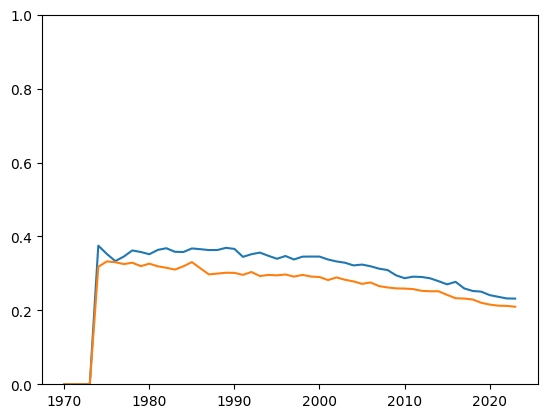

In [ ]:
plt.plot(df_dist_rolling_yearly_ind.dropna(how="all").median(axis=1).groupby(level=1).median().to_frame("mean_dist").index,
         df_dist_rolling_yearly_ind.dropna(how="all").median(axis=1).groupby(level=1).median().to_frame("mean_dist").mean_dist)
plt.plot(df_dist_rolling_yearly_col.dropna(how="all").median(axis=1).groupby(level=1).median().to_frame("mean_dist").index,
         df_dist_rolling_yearly_col.dropna(how="all").median(axis=1).groupby(level=1).median().to_frame("mean_dist").mean_dist)
plt.ylim(0, 1)